# 05- Dự đoán khách hàng có đăng ký hay không

Bộ notebook này thực hiện:
- nạp dữ liệu đã xử lý
- đánh giá nhiều mô hình phân loại
- so sánh và trực quan hóa kết quả
- lưu báo cáo hiệu năng

Thiết kế theo chuẩn để đạt điểm cao trong đồ án (đầy đủ, có giải thích, tái sử dụng được).

In [6]:
# 1) Cài đặt và import thư viện
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# matplotlib style
try:
    plt.style.use('seaborn')
except OSError:
    plt.style.use('default')

# Đặt đường dẫn tương đối để tái sử dụng
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..')) if 'ucimlrepo' in os.getcwd() else os.getcwd()
DATA_PATH = os.path.join(ROOT, 'ucimlrepo', 'data', 'processed', 'bank_clean.csv')
print('ROOT', ROOT)
print('DATA_PATH', DATA_PATH)

ROOT c:\Users\Duong\OneDrive - Dai Nam University\Desktop\data-BTL
DATA_PATH c:\Users\Duong\OneDrive - Dai Nam University\Desktop\data-BTL\ucimlrepo\data\processed\bank_clean.csv


In [7]:
# 2) Nạp dữ liệu
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'Data file not found: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
print('Dữ liệu chứa', df.shape[0], 'dòng và', df.shape[1], 'cột')
df.head()

Dữ liệu chứa 4521 dòng và 17 cột


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,10,1,0,0,1787,0,0,0,19,10,79,1,-1,0,3,0
1,33,7,1,1,0,4789,1,1,0,11,8,220,1,339,4,0,0
2,35,4,2,2,0,1350,1,0,0,16,0,185,1,330,1,0,0
3,30,4,1,2,0,1476,1,1,2,3,6,199,4,-1,0,3,0
4,59,1,1,1,0,0,1,0,2,5,8,226,1,-1,0,3,0


<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   int64
 2   marital    4521 non-null   int64
 3   education  4521 non-null   int64
 4   default    4521 non-null   int64
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   int64
 7   loan       4521 non-null   int64
 8   contact    4521 non-null   int64
 9   day        4521 non-null   int64
 10  month      4521 non-null   int64
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   int64
 16  y          4521 non-null   int64
dtypes: int64(17)
memory usage: 600.6 KB
None

Thống kê mô tả:
            count         mean          std     min    25%    50%     75%  \
age        4521.0    41.170095    10.57621

C:\Users\Duong\AppData\Local\Temp\ipykernel_12636\1721847743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='y', data=df, palette='Set2')


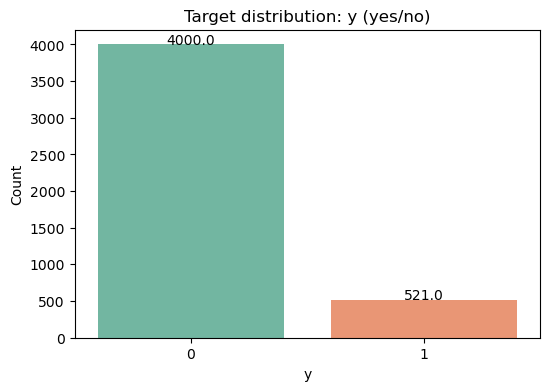

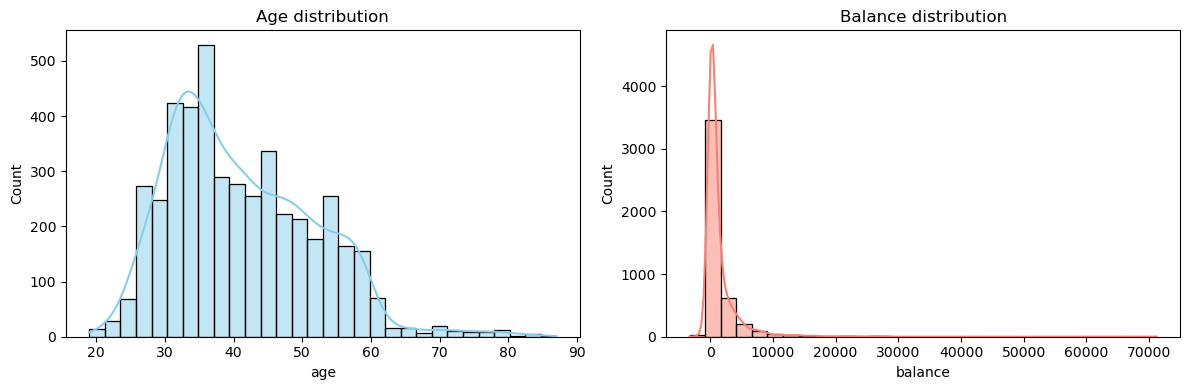

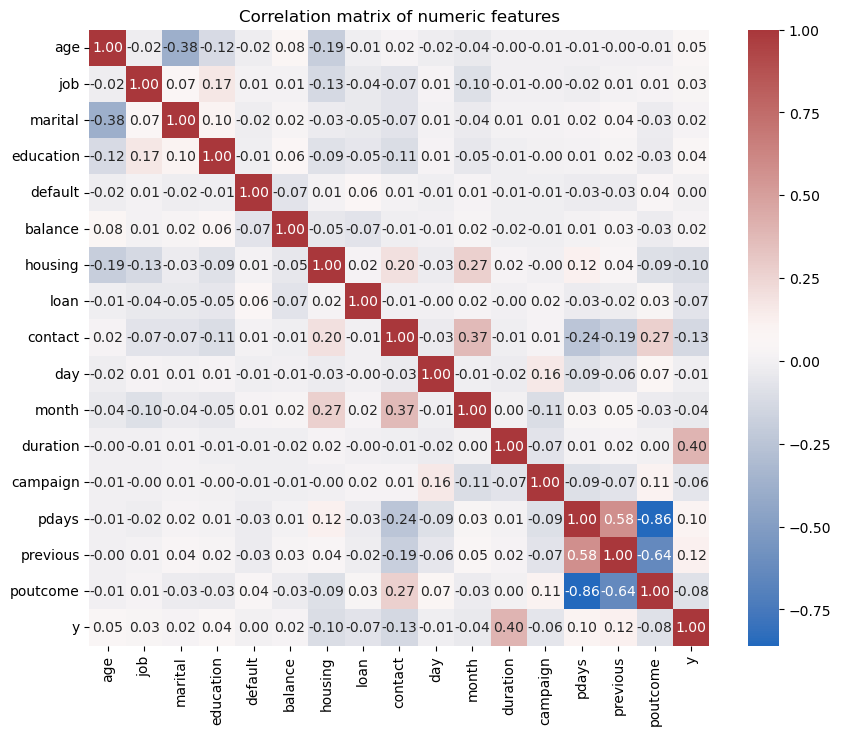

In [8]:
# 3) Thống kê nhanh và kiểm tra missing
print(df.info())
print('\nThống kê mô tả:')
print(df.describe(include='all').T)

# tỷ lệ lớp target
if 'y' in df.columns:
    print('\nTarget value counts:')
    print(df['y'].value_counts(normalize=True).round(3))

# 3.1) Biểu đồ 1: phân phối target
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='y', data=df, palette='Set2')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 5, f'{height}', ha='center')
plt.title('Target distribution: y (yes/no)')
plt.ylabel('Count')
plt.show()

# 3.2) Biểu đồ 2: phân bổ numeric (ví dụ age và balance)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'age' in num_cols and 'balance' in num_cols:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
    plt.title('Age distribution')

    plt.subplot(1, 2, 2)
    sns.histplot(df['balance'], bins=30, kde=True, color='salmon')
    plt.title('Balance distribution')
    plt.tight_layout()
    plt.show()

# 3.3) Biểu đồ 3: heatmap correlation
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag')
    plt.title('Correlation matrix of numeric features')
    plt.show()

In [9]:
# 4) Tiền xử lý: mã hóa và chia dữ liệu
TARGET = 'y'
if TARGET not in df.columns:
    raise ValueError('Cột target y không tồn tại')

X = df.drop(columns=[TARGET])
y = df[TARGET].copy()

# Áp dụng label encode cho target nêu là Yes/No
if y.dtype == 'object':
    y = (y.str.lower() == 'yes').astype(int)

# mã hóa các cột biến categorical
cat_cols = X.select_dtypes(include='object').columns.tolist()
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# chuẩn hóa
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (3390, 16) Test: (1131, 16)


In [10]:
# 5) Hàm hỗ trợ đánh giá

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0)
    }
    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_proba)

    print('\n===== Evaluation: {} ====='.format(model.__class__.__name__))
    print('Accuracy:', metrics['accuracy'])
    print('Precision:', metrics['precision'])
    print('Recall:', metrics['recall'])
    print('F1 score:', metrics['f1'])
    if 'roc_auc' in metrics:
        print('ROC AUC:', metrics['roc_auc'])

    print('\nClassification report:')
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {model.__class__.__name__}')
    plt.show()

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {metrics["roc_auc"]:.3f})')
        plt.plot([0, 1], [0, 1], '--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC curve: {model.__class__.__name__}')
        plt.legend(loc='lower right')
        plt.show()

    return metrics


===== Evaluation: LogisticRegression =====
Accuracy: 0.8841732979664014
Precision: 0.4897959183673469
Recall: 0.18461538461538463
F1 score: 0.2681564245810056
ROC AUC: 0.8546069315300084

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1001
           1       0.49      0.18      0.27       130

    accuracy                           0.88      1131
   macro avg       0.70      0.58      0.60      1131
weighted avg       0.85      0.88      0.86      1131



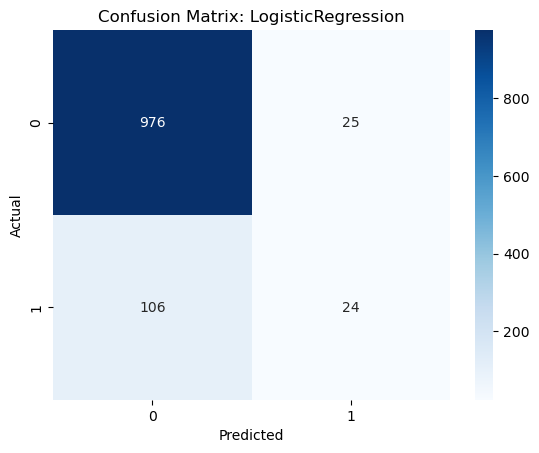

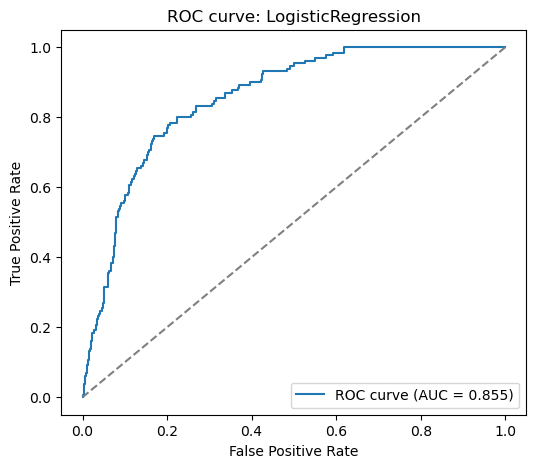


===== Evaluation: RandomForestClassifier =====
Accuracy: 0.8938992042440318
Precision: 0.5735294117647058
Recall: 0.3
F1 score: 0.3939393939393939
ROC AUC: 0.8853223699377546

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1001
           1       0.57      0.30      0.39       130

    accuracy                           0.89      1131
   macro avg       0.74      0.64      0.67      1131
weighted avg       0.88      0.89      0.88      1131



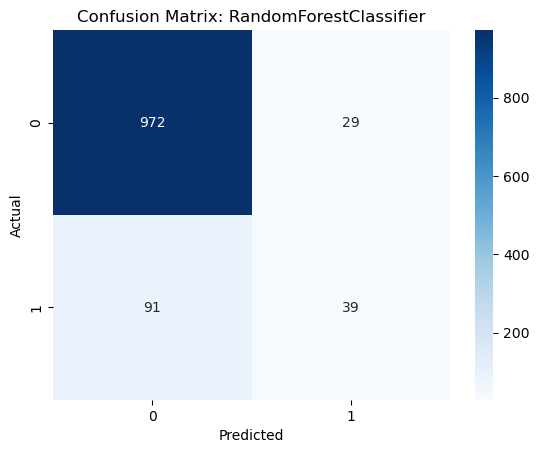

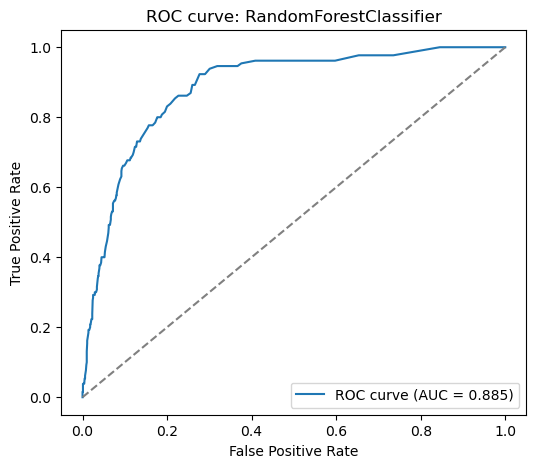


===== Evaluation: SVC =====
Accuracy: 0.8938992042440318
Precision: 0.65625
Recall: 0.16153846153846155
F1 score: 0.25925925925925924
ROC AUC: 0.818658264812111

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      1001
           1       0.66      0.16      0.26       130

    accuracy                           0.89      1131
   macro avg       0.78      0.58      0.60      1131
weighted avg       0.87      0.89      0.86      1131



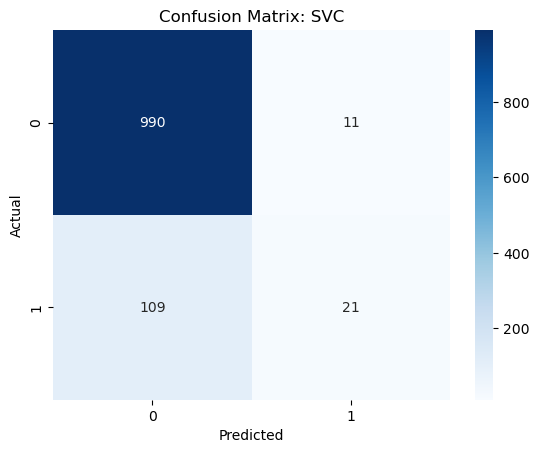

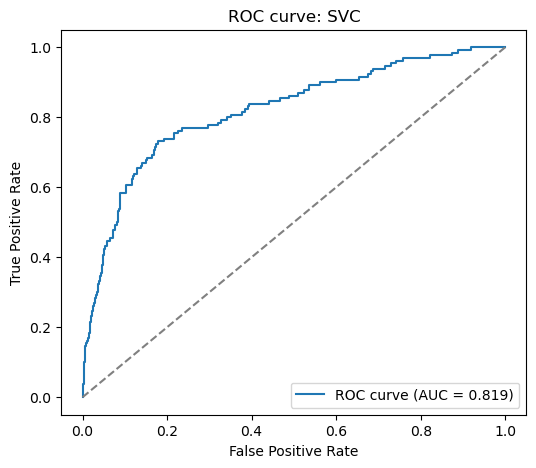

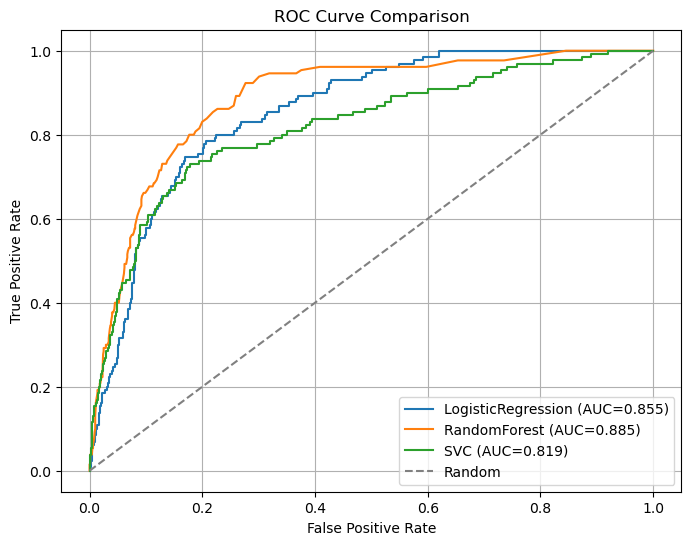

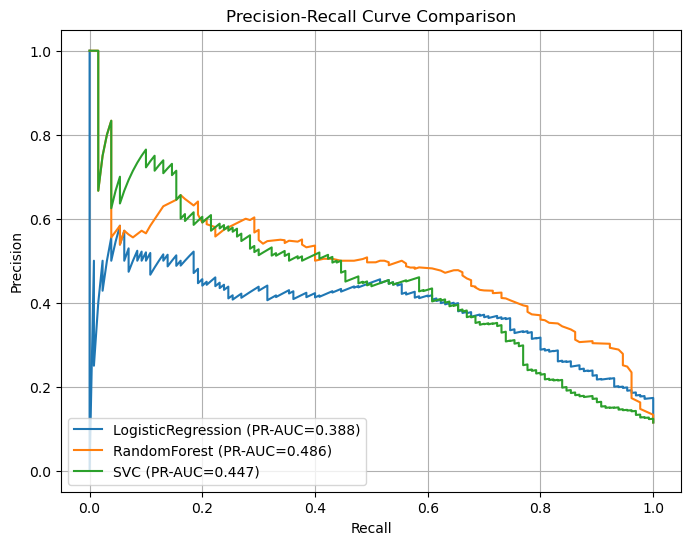

In [11]:
# 6) Huấn luyện và so sánh nhiều mô hình
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVC': SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}
model_objects = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    model_objects[name] = model
    results[name] = evaluate_model(model, X_test, y_test)

results_df = pd.DataFrame(results).T
results_df

# 6.1) ROC curves so sánh
plt.figure(figsize=(8, 6))
for name, model in model_objects.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], '--', color='grey', label='Random')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 6.2) PR curve (nếu có threshold) and Bar chart
from sklearn.metrics import precision_recall_curve, auc
plt.figure(figsize=(8, 6))
for name, model in model_objects.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f'{name} (PR-AUC={pr_auc:.3f})')

plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

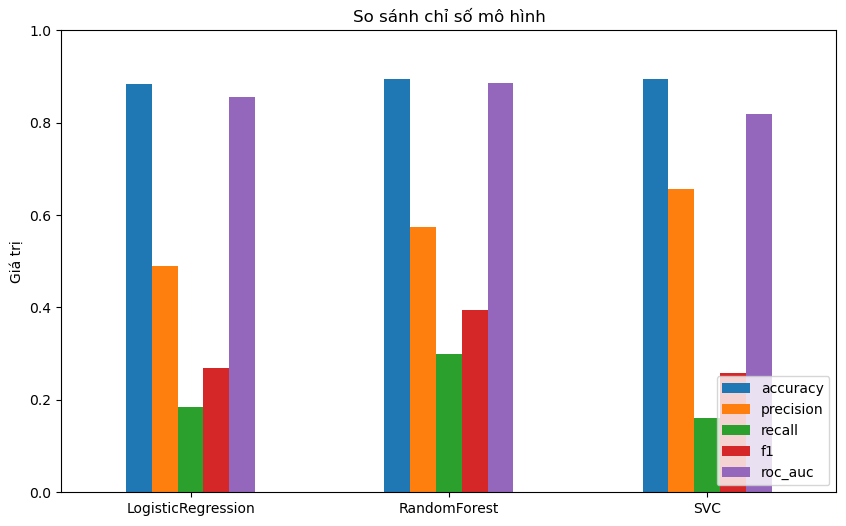

In [12]:
# 7) So sánh trực quan các chỉ số
results_df.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('So sánh chỉ số mô hình')
plt.ylabel('Giá trị')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

In [13]:
# 8) Nếu cần: xuất báo cáo
os.makedirs(os.path.join(ROOT, 'ucimlrepo', 'outputs', 'reports'), exist_ok=True)
report_path = os.path.join(ROOT, 'ucimlrepo', 'outputs', 'reports', 'model_evaluation_summary.csv')
results_df.to_csv(report_path, index=True)
print('Saved evaluation report to', report_path)

Saved evaluation report to c:\Users\Duong\OneDrive - Dai Nam University\Desktop\data-BTL\ucimlrepo\outputs\reports\model_evaluation_summary.csv


## Kết luận
- Chọn mô hình có F1 / ROC AUC tốt nhất tùy yêu cầu nghiệp vụ (imbalanced, false positive/negative quan trọng?).
- Có thể mở rộng: tuning GridSearchCV, xử lý imbalance (SMOTE), thêm pipeline và lưu model `joblib`.